In [ ]:
import pandas as pd
import os
import glob

folder = r"C:\Users\amira\Downloads\SUC1dataset"
files = glob.glob(os.path.join(folder, "*.csv"))

dfs = []

for f in files:
    name = os.path.basename(f)


    if "Measurements" not in name:
        continue

    print("Loading:", name)
    df = pd.read_csv(f)

   
    if "time_datetime" in df.columns:
        df["time_datetime"] = pd.to_datetime(df["time_datetime"])

    # label
    if "Error" in df.columns:
        df["attack"] = df["Error"].astype(int)
        df = df.drop(columns=["Error"])
    else:
        df["attack"] = 0

 
    scenario = name.split("_")[2]   # S1 S2 S3 S4
    df["scenario"] = scenario

   
    if scenario in ["S1","S2"]:
        df["attack_type"] = "physics"
    elif scenario == "S3":
        df["attack_type"] = "control"
    elif scenario == "S4":
        df["attack_type"] = "network"

    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print("\nFinal combined shape:", dataset.shape)
print(dataset["scenario"].value_counts())
print(dataset["attack"].value_counts())


Loading: Electron_SUC1_S1_Pwind_Attack_Measurements.csv
Loading: Electron_SUC1_S2_Pbss_meas_Attack_Measurements.csv
Loading: Electron_SUC1_S3_Pbss_ref_Attack_Measurements.csv
Loading: Electron_SUC1_S4_Modbus_MITM_Attack_Measurements.csv

Final combined shape: (797, 14)
scenario
S1    242
S2    206
S3    205
S4    144
Name: count, dtype: int64
attack
0    781
1     16
Name: count, dtype: int64


C:\Users\amira\AppData\Local\Temp\ipykernel_33528\1575558303.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time_datetime"] = pd.to_datetime(df["time_datetime"])


In [7]:
out = r"C:\Users\amira\Downloads\SUC1dataset\combined_measurements.csv"
dataset.to_csv(out, index=False)
print("Saved:", out)


Saved: C:\Users\amira\Downloads\SUC1dataset\combined_measurements.csv


In [9]:
import pandas as pd

df = dataset.copy()

print("\nDataset shape:", df.shape)
print("\nFeatures:", list(df.columns))

print("\nAttack ratio:", df["attack"].mean())

print("\nAttacks per scenario:")
print(df.groupby("scenario")["attack"].sum())

print("\nDuration per scenario:")
print(df.groupby("scenario")["time_datetime"].agg(["min","max"]))



Dataset shape: (797, 14)

Features: ['time_datetime', 'Pbss', 'Pbss_bus8_Bus8_bTX', 'Pbss_bus8_real', 'Pbss_bus8_ref_real', 'Pbss_ref', 'Phres', 'Phres_real', 'Phres_ref', 'Ptot_wind1_real', 'Pwind', 'attack', 'scenario', 'attack_type']

Attack ratio: 0.020075282308657464

Attacks per scenario:
scenario
S1     0
S2     0
S3     0
S4    16
Name: attack, dtype: int64

Duration per scenario:
                         min                 max
scenario                                        
S1       2024-05-17 15:43:01 2024-05-17 16:05:04
S2       2024-05-24 05:38:29 2024-05-24 05:57:12
S3       2026-02-13 15:45:50 2026-02-13 16:04:25
S4       2024-05-20 11:39:37 2024-05-20 11:58:26


In [ ]:


def feature_role(col: str) -> str:
    c = col.lower()
    if c in ["attack", "scenario", "attack_type", "time_datetime"]:
        return "metadata/label"
    if "ref" in c:
        return "controller reference (setpoint)"
    if "real" in c:
        return "physical measurement (sensor)"
    if "btx" in c:
        return "control/communication parameter"
    if c in ["pbss", "phres", "pwind"]:
        return "internal/control variable"
    return "other"

feature_info = pd.DataFrame({
    "feature": df.columns,
    "role": [feature_role(c) for c in df.columns]
})

print(feature_info)


               feature                             role
0        time_datetime                   metadata/label
1                 Pbss        internal/control variable
2   Pbss_bus8_Bus8_bTX  control/communication parameter
3       Pbss_bus8_real    physical measurement (sensor)
4   Pbss_bus8_ref_real  controller reference (setpoint)
5             Pbss_ref  controller reference (setpoint)
6                Phres        internal/control variable
7           Phres_real    physical measurement (sensor)
8            Phres_ref  controller reference (setpoint)
9      Ptot_wind1_real    physical measurement (sensor)
10               Pwind        internal/control variable
11              attack                   metadata/label
12            scenario                   metadata/label
13         attack_type                   metadata/label


Top 15 important features:
Phres_real            0.193029
Wind_err              0.159003
Phres                 0.125093
Pbss_ref              0.113711
Ptot_wind1_real       0.091684
Pbss_bus8_ref_real    0.080089
Pbss_bus8_real        0.077159
Pbss_bus8_Bus8_bTX    0.058900
Pbss                  0.055422
Pwind                 0.037937
Pbss_err              0.004291
Phres_err             0.003533
Phres_ref             0.000147
dtype: float64


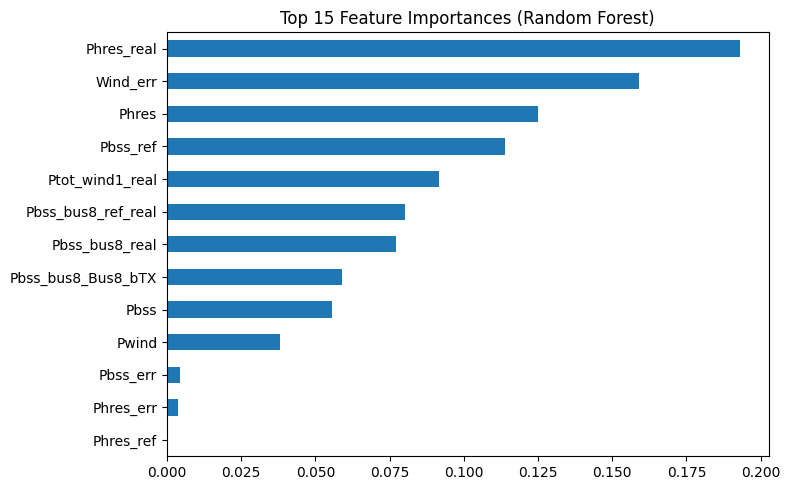

In [ ]:


from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Build X/y
X = df.select_dtypes(include="number").drop(columns=["attack"])
y = df["attack"].astype(int)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced" 
)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 important features:")
print(importance.head(15))

plt.figure(figsize=(8,5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
